## Detección de cambio semántico


Para controlar la visualizacion usar:
* https://www.color-blindness.com/coblis-color-blindness-simulator/
* https://colorbrewer2.org/#type=diverging&scheme=BrBG&n=3

In [1]:
# Cargar las librerías necesarias
from dotenv import load_dotenv
import pandas as pd
import pickle 
import os
import sys
import numpy as np
from scipy import stats
import ast

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
load_dotenv() 

True

In [2]:
HEALTH_CYAN = "#0077A8"   # celeste medio
GRAY_MAIN   = "#8F8F8F"
GRAY_LIGHT  = "#E0E0E0"
GRAY_DARK   = "#3A3A3A"

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import locale
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

#locale.setlocale(locale.LC_ALL, 'es_AR.UTF-8')
#'es_ES.UTF-8'
#'es_ES'
#'spanish'

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=[HEALTH_CYAN, GRAY_MAIN, GRAY_LIGHT, GRAY_DARK]
)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "font.size": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.edgecolor": "#2B2B2B",
    "axes.labelcolor": "#2B2B2B",
    "text.color": "#2B2B2B",
    "grid.color": "#E5E5E5",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "legend.fontsize": 18,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})


### Lectura de datos


In [4]:
# Configurar path
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env modelos_swmwosge_1008211100
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno modelos_swmwosge_50881200
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_5051100'
pd.set_option('display.max_colwidth', None)

In [5]:
metodos = ['procrustes', 'NN']
score = ['promedio de similitud coseno', 'promedio de puntaje de cambio (score) k']
iteracion = 50
tam_vector = 50
pares_periodo = [ (2009, 2014),(2014, 2019)]

In [18]:
def get_similitud(basename1, topn_periodo1):
    similitud1 = []
    topk = 5
    for par_periodo in pares_periodo:
        df = topn_periodo1[par_periodo].sort_values('similaridad_semantica_mean')
        #df["par_periodo"] = df["par_periodo"].apply(ast.literal_eval)
        print("*************************")
        print(par_periodo)
        print("*************************")
        print(df.shape)
        #display(df.head(topk))
        #display(df.describe())
        similitud1.append(df)
    return similitud1

def mostrar_metrica(m1,m2):
    # Test estadístico para diferencia de distribuciones
    t_stat, p_value = stats.ttest_ind(m1, m2)
    
    print("ANÁLISIS ESTADÍSTICO DE "+basemetrica.upper())
    print(f"2009 - 2014: Media = {m1.mean():.2f} ± {m1.std():.2f}")
    print(f"2014 - 2019: Media = {m2.mean():.2f} ± {m2.std():.2f}")
    print(f"Diferencia: {m1.mean() - m2.mean():.2f}")
    print(f"Test t: t = {t_stat:.3f}, p-value = {p_value:.2f}")
    print(f"Significativo (p < 0.05): {'SÍ' if p_value < 0.05 else 'NO'}")


def visualizacion_metrica_enfoque(metrica_df,basemetrica,metrica_2009_2014,metrica_2014_2019):
    

    # Paleta optimizada para similitud coseno
    PALETA_COSENO = {
        (2009, 2014): '#253494',  # azul oscuro
        (2014, 2019): '#D95F0E'    # naranja intenso
    }
    
    
    plt.figure(figsize=(14, 10))
    # Gráfico principal
    sns.kdeplot(
        data=metrica_df,
        x='similaridad_semantica_mean',
        hue='par_periodo',
        palette=PALETA_COSENO,
        fill=True,
        alpha=0.3,
        common_norm=False
    )
    
    plt.xlabel(basemetrica.capitalize(), fontsize=18, fontweight='bold')
    plt.ylabel('Densidad', fontsize=18, fontweight='bold')
    #plt.title('Distribución de densidad de promedio de similitud coseno', fontsize=14, fontweight='bold')
    
    
    # Calcular medias
    media_2009_2014 = metrica_2009_2014.mean()
    media_2014_2019 = metrica_2014_2019.mean()
    diferencia_medias = abs(media_2009_2014 - media_2014_2019)
    
    # Elementos visuales clave
    plt.axvline(media_2009_2014, color=PALETA_COSENO[(2009, 2014)], linestyle='--', linewidth=3, alpha=0.8)
    plt.axvline(media_2014_2019, color=PALETA_COSENO[(2014, 2019)], linestyle='--', linewidth=3, alpha=0.8)
    plt.axvspan(min(media_2009_2014, media_2014_2019), max(media_2009_2014, media_2014_2019), 
                alpha=0.2, color='gray')
    
    
    legend_elements = [
        Patch(facecolor=PALETA_COSENO[(2009, 2014)], alpha=0.5, label=r'$C_{t_1}$–$C_{t_2}$'),
        Patch(facecolor=PALETA_COSENO[(2014, 2019)], alpha=0.5, label=r'$C_{t_2}$–$C_{t_3}$'),
        plt.Line2D([0], [0], color=PALETA_COSENO[(2009, 2014)], linestyle='--', linewidth=2, 
                   label=rf'Media $C_{{t_1}}$–$C_{{t_2}}$: {media_2009_2014:.2f}'), #{locale.format_string('%.2f', media_2009_2014)}
        plt.Line2D([0], [0], color=PALETA_COSENO[(2014, 2019)], linestyle='--', linewidth=2, 
                   label=rf'Media $C_{{t_2}}$–$C_{{t_3}}$: {media_2014_2019:.2f}') ,# locale.format_string('%.2f', media_2014_2019)
         Patch(facecolor='gray', alpha=0.2, label=f"Diferencias de medias: {diferencia_medias:.2f}") #{locale.format_string('%.2f', diferencia_medias)}
     
    ]
    
    plt.legend(handles=legend_elements, loc='best', frameon=False, shadow=True)
    
    # Spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    
    
    formatter = FuncFormatter(lambda x, pos: locale.format_string('%.2f', x))
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)
    
    plt.grid(False)
    
    plt.tight_layout(pad=3)
    plt.savefig(BASE_DIR+'imagenes/'+basemetrica+'.png', 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

*************************
(2009, 2014)
*************************
(345, 8)
*************************
(2014, 2019)
*************************
(335, 8)
ANÁLISIS ESTADÍSTICO DE PROMEDIO DE SIMILITUD COSENO
2009 - 2014: Media = 0.60 ± 0.08
2014 - 2019: Media = 0.58 ± 0.09
Diferencia: 0.02
Test t: t = 2.347, p-value = 0.02
Significativo (p < 0.05): SÍ


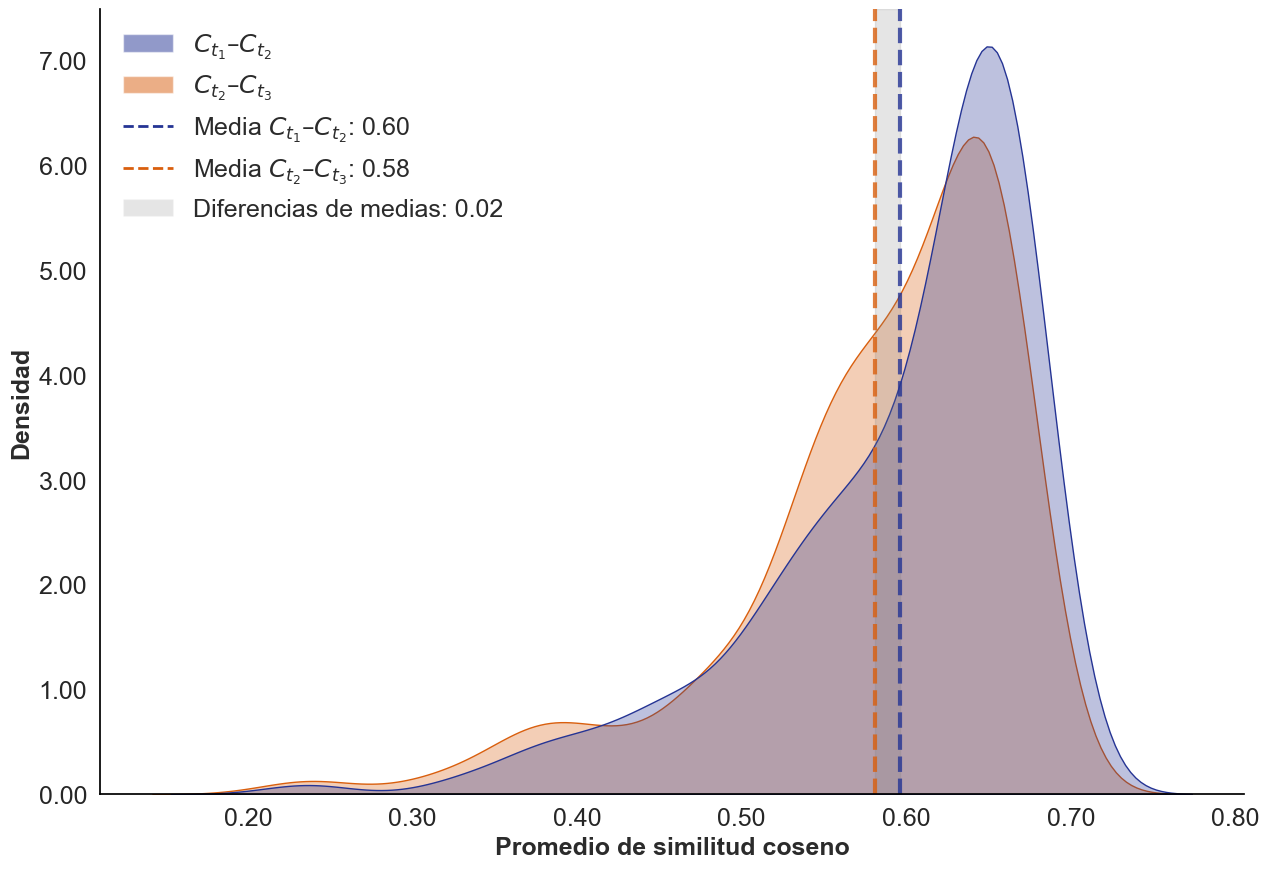

*************************
(2009, 2014)
*************************
(330, 8)
*************************
(2014, 2019)
*************************
(356, 8)
ANÁLISIS ESTADÍSTICO DE PROMEDIO DE PUNTAJE DE CAMBIO (SCORE) K
2009 - 2014: Media = -4.51 ± 1.56
2014 - 2019: Media = -3.42 ± 1.43
Diferencia: -1.09
Test t: t = -9.572, p-value = 0.00
Significativo (p < 0.05): SÍ


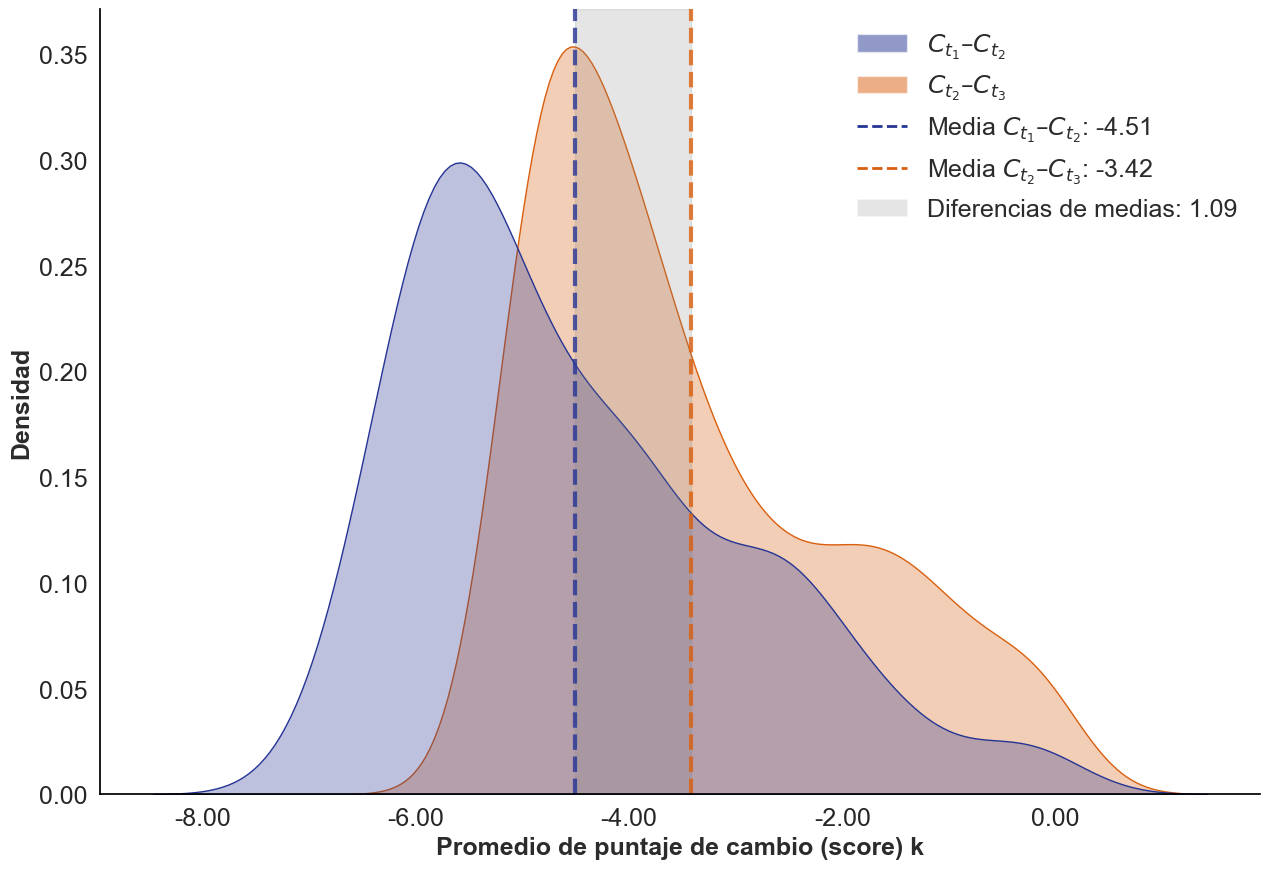

In [19]:
# Abrir OBJETO
i = 0
for basemetrica , basename in zip(score,metodos):
    with open(modelo_dir+'/top250_periodos_'+basename+'_df.pkl', 'rb') as file: 
        topn_periodo = pickle.load(file) ## Diccionario


    similitud = get_similitud(basename,topn_periodo)

    metrica_df = pd.concat(similitud, axis=0)
    metrica_df = metrica_df[['similaridad_semantica_mean','par_periodo']]

    # Calcular estadísticas
    metrica_2009_2014_1 = metrica_df[metrica_df['par_periodo']==(2009, 2014)]['similaridad_semantica_mean']
    metrica_2014_2019_1 = metrica_df[metrica_df['par_periodo']==(2014, 2019)]['similaridad_semantica_mean']
    mostrar_metrica(metrica_2009_2014_1,metrica_2014_2019_1)
    visualizacion_metrica_enfoque(metrica_df,basemetrica,metrica_2009_2014_1,metrica_2014_2019_1)
